In [60]:
'''
현재까지의 진행 상황:
    1. LangGraph에 대한 기초적인 이해 - Node, Edge, State등의 개념을 이해하고
    2. 이를 바탕으로 이전에 해봤던 기초적인 RAG를 LangGraph 방식으로 build하고 compile 해봤다.
    3. 더 나아가 사용자의 질문과 Retrieved doc의 연관도를 판단하고, 필요시 query를 재작성하는 conditional edge를 추가했다.


조건부 분기나 Human-in-the-loop, Self-RAG, 더 나아가 멀티 에이전트 또는 MCP까지 시도하고 싶다.

이번엔 생성된 답변을 수 차례 검증하는 Self-RAG를 구현할 것이며,
앞으로는 Human-in-the-loop를 구현해 보려고 한다.
'''

'\n현재까지의 진행 상황:\n    1. LangGraph에 대한 기초적인 이해 - Node, Edge, State등의 개념을 이해하고\n    2. 이를 바탕으로 이전에 해봤던 기초적인 RAG를 LangGraph 방식으로 build하고 compile 해봤다.\n    3. 더 나아가 사용자의 질문과 Retrieved doc의 연관도를 판단하고, 필요시 query를 재작성하는 conditional edge를 추가했다.\n\n\n조건부 분기나 Human-in-the-loop, Self-RAG, 더 나아가 멀티 에이전트 또는 MCP까지 시도하고 싶다.\n\n이번엔 생성된 답변을 수 차례 검증하는 Self-RAG를 구현할 것이며,\n앞으로는 Human-in-the-loop를 구현해 보려고 한다.\n'

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma


embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,
        'fetch_k': 50,
        'lamda_mult': 0.6
    }
)

In [3]:
from langchain_anthropic import ChatAnthropic
from langsmith import Client


client = Client()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [4]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [5]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Literal


def retrieve(state: AgentState):
    query  = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

relevance_check_prompt = client.pull_prompt('langchain-ai/rag-document-relevance')


def doc_relevance_check(state: AgentState) -> Literal['generate', 'rewrite']:   # 앞으로 많이 보게 될 typehint 스타일
    context = state['context']
    query = state['query']
    doc_relevance_chain = relevance_check_prompt | llm
    response = doc_relevance_chain.invoke({'documents': context, 'question': query})

    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'


rewrite_prompt = PromptTemplate.from_template("""
당신은 한국 세법 전문가입니다.
사용자의 질문을 소득세법 문서 검색에 최적화된 형태로 다시 작성하세요.

규칙:
1. 일상 용어를 법률 용어로 변환 (예: 월급 → 근로소득)
2. 모호한 표현을 구체화
3. 검색에 필요한 핵심 키워드 포함

예시:
    소득 관련
    '월급, 급여 -> 근로소득',
    '집 팔 때 세금, 부동산 양도 -> 양도소득세',
    '이자, 배당 -> 금융소득',
    '프리랜서 수입, 외주 -> 사업소득',
    '강연료, 원고료 -> 기타소득',
    
    공제 관련
    '부양가족 공제 -> 인적공제',
    '카드 공제 -> 신용카드 소득공제',
    '의료비 공제 -> 의료비 세액공제',
    
    일반 표현
    '세금 돌려받기 -> 환급',
    '세금 신고 -> 확정신고',
    '직장인 연말 세금 -> 연말정산'

원본 질문: {query}
Retrieve 최적화된 질문:
""")

def rewrite(state: AgentState) -> AgentState:
    """
    사용자의 질문을 법률 용어에 적합하게 변경

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 변경된 질문을 포함하는 state를 반환
    """
    
    query = state['query']  # state에서 사용자의 질문 추출
    
    # rewrite 체인을 구성 프롬프트, LLM, 출력 파서 연결
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    # query 변경
    response = rewrite_chain.invoke({'query': query})
    
    return {'query': response}  # 변경된 질문을 포함하는 state 반환


generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    answer = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'context': context, 'question': answer})
    return {'answer': response.content} 

## halluciantion check

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

hallucination_check_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 AI 답변의 정확성을 평가하는 검증자입니다.

주어진 context(참고 문서)만을 기준으로, 생성된 답변이 hallucination(환각)을 포함하는지 판단하세요.

평가 기준:
1. 답변의 모든 정보가 context에 근거하는가?
2. context에 없는 내용을 지어내지 않았는가?
3. 숫자, 날짜, 법조항 등 구체적 정보가 정확한가?

점수:
- 1점: 답변이 context에 충실함 (hallucination 없음)
- 0점: 답변에 context에 없는 정보가 포함됨 (hallucination 있음)

반드시 아래 형식으로 응답하세요:
Score: [0 또는 1]
Explanation: [판단 이유]
"""),
    ("human", """
Context:
{context}

생성된 답변:
{answer}

위 답변이 context에 충실한지 평가해주세요.
""")
])

hallucination_llm = ChatAnthropic(model='claude-haiku-4-5-20251001', temperature=0)

def hallucination_check(state: AgentState) -> Literal['end', 'regenerate']:
    answer = state['answer']
    context = state['context']
    context = [doc.page_content for doc in context]
    hallucination_chain = hallucination_check_prompt | hallucination_llm | StrOutputParser()
    response = hallucination_chain.invoke({'student_answer': answer, 'documents': context})

    return response

In [ ]:
query = '원천징수 대상 기타소득에는 어떤 것이 있나요?'
context = retriever.invoke(query)


generate_state = {'query': query, 'context': context}
generated = generate(generate_state)

halu_state = {'query': query, 'context': context, 'answer': generated['answer']}

hallu_hallu = hallucination_check(halu_state)

document
③ 연금소득금액은 제1항 각 호에 따른 소득의 금액의 합계액(제2항에 따라 연금소득에서 제외되는 소득과 비과세소득의 금액은 제외하며, 이하 “총연금액”이라 한다)에서 제47조의2에 따른 연금소득공제를 적용한 금액으로 한다.

④ 연금소득의 범위 및 계산방법과 그 밖에 필요한 사항은 대통령령으로 정한다.

[전문개정 2009. 12. 31.]



제21조(기타소득) ① 기타소득은 이자소득ㆍ배당소득ㆍ사업소득ㆍ근로소득ㆍ연금소득ㆍ퇴직소득 및 양도소득 외의 소득으로서 다음 각 호에서 규정하는 것으로 한다. <개정 2009. 7. 31., 2010. 12. 27., 2012. 1. 1., 2013. 1. 1., 2014. 12. 23., 2015. 12. 15., 2016. 12. 20., 2017. 12. 19., 2018. 12. 31., 2019. 8. 27., 2020. 12. 29., 2024. 12. 31.>

1. 상금, 현상금, 포상금, 보로금 또는 이에 준하는 금품

2. 복권, 경품권, 그 밖의 추첨권에 당첨되어 받는 금품

3. 「사행행위 등 규제 및 처벌특례법」에서 규정하는 행위(적법 또는 불법 여부는 고려하지 아니한다)에 참가하여 얻은 재산상의 이익

4. 「한국마사회법」에 따른 승마투표권, 「경륜ㆍ경정법」에 따른 승자투표권, 「전통소싸움경기에 관한 법률」에 따른 소싸움경기투표권 및 「국민체육진흥법」에 따른 체육진흥투표권의 구매자가 받는 환급금(발생 원인이 되는 행위의 적법 또는 불법 여부는 고려하지 아니한다)

5. 저작자 또는 실연자(實演者)ㆍ음반제작자ㆍ방송사업자 외의 자가 저작권 또는 저작인접권의 양도 또는 사용의 대가로 받는 금품

6. 다음 각 목의 자산 또는 권리의 양도ㆍ대여 또는 사용의 대가로 받는 금품

가. 영화필름

나. 라디오ㆍ텔레비전방송용 테이프 또는 필름

다. 그 밖에 가목 및 나목과 유사한 것으로서 대통령령으로 정하는 것
다. 변호사, 공인회계사, 세무사, 건축사, 측량사, 변리사, 그 밖에 전문적 지식

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import START, END


graph_builder = StateGraph(AgentState)

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)


graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', doc_relevance_check)    # 앞에 doc_relevance_check에 typehint
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

graph = graph_builder.compile()

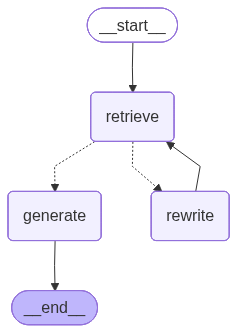

In [ ]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
query='연봉 5000만원인 사람의 산출세액은?'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [ ]:
response

연봉 5,000만원인 사람의 산출세액을 계산하려면 먼저 근로소득공제 등을 적용하여 과세표준을 구한 후 세율표를 적용해야 합니다. 제공된 세율표에 따르면, 과세표준이 1,400만원 초과 5,000만원 이하인 경우 "84만원 + (1,400만원을 초과하는 금액의 15%)"로 계산됩니다. 다만 정확한 산출세액을 계산하려면 근로소득공제, 인적공제 등 각종 공제사항이 적용된 과세표준 금액이 필요합니다.